A projektünk több, mint 30000 Spotify dalnak az adatait elemeztük statisztikai és adatvizualizációs módszerekkel.
Forrás: Kaggle(Google)
Link: https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs

Változóink:

track_popularity: 0 és 100 közötti változó, mely az adott zene népszerűségét méri (100 a legnépszerűbb)

track_album_release_date: a zene kiadásának dátuma

playlist_genre: a zene műfaja

danceability: 0 és 1 közötti változó, ami a zene ritmusa és stabilitása alapján méri azt, hogy mennyire jó rá táncolni (1 a legjobb)

energy: 0 és 1 közötti változó, mely azt méri, hogy mennyire energikus (azaz hangos, pörgős) az adott zene (1 a leginkább energikus)

mode: egy dummy változó, mely azt mutatja, hogy az adott szám dúr (vidámabb) vagy moll (borongósabb) hangnemben íródott - a dúr az 1, a moll a 0

tempo: a zene tempója BPM-ben (Beats per minute = percenkénti leütésszám) mérve

duration_ms: a szám hossza milliszekundumokban mérve

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from collections import Counter

# adatok beolvasása
spot = pd.read_excel('spotify_zene.xlsx')
spot = spot.dropna()

# saját KNN algoritmus készítése

# kiválasztjuk a numerikus prediktorokat
prediktorok = ['danceability', 'energy', 'tempo', 'duration_ms']

# sztenderdizáljuk őket

prediktorok_std = spot[prediktorok].copy()

for oszlop in prediktorok:
    atlag = prediktorok_std[oszlop].mean()
    szoras = prediktorok_std[oszlop].std()

    prediktorok_std[oszlop] = (prediktorok_std[oszlop] - atlag) / szoras

# az algoritmus az első 30000 adaton fog tanulni

tanito_adatok = prediktorok_std.iloc[:30000].values.tolist()
tanito_cimkek = spot['playlist_genre'].iloc[:30000].values.tolist()

# megpróbáljuk az algoritmussal megtippelni a 30001. dal műfaját

uj_adat = prediktorok_std.iloc[30000].values.tolist()
valos_mufaj = spot['playlist_genre'].iloc[30000]

def sajat_knn(tanito_adatok, tanito_cimkek, uj_adat, k):
    tavolsagok = []

    for i in range(len(tanito_adatok)):
        tavolsag = np.sqrt(np.sum((np.array(tanito_adatok[i]) - np.array(uj_adat))**2))
        tavolsagok.append((tavolsag, tanito_cimkek[i]))

    tavolsagok.sort(key = lambda x: x[0])
    szomszedok = tavolsagok[:k]

    mufajok = [szomszed[1] for szomszed in szomszedok]
    tipp = Counter(mufajok).most_common(1)

    return tipp[0][0]


predikcio = sajat_knn(tanito_adatok, tanito_cimkek, uj_adat, 5)

print(f'A KNN jóslata: {predikcio}')
print(f'Az igazi műfaj: {valos_mufaj}')



A KNN jóslata: rap
Az igazi műfaj: edm


,danceability,energy,tempo,duration_ms
danceability,1.000000,-0.086074,-0.184132,-0.096922
energy,-0.086074,1.000000,0.150072,0.012560
tempo,-0.184132,0.150072,1.000000,-0.001347
duration_ms,-0.096922,0.012560,-0.001347,1.000000


<Axes: >

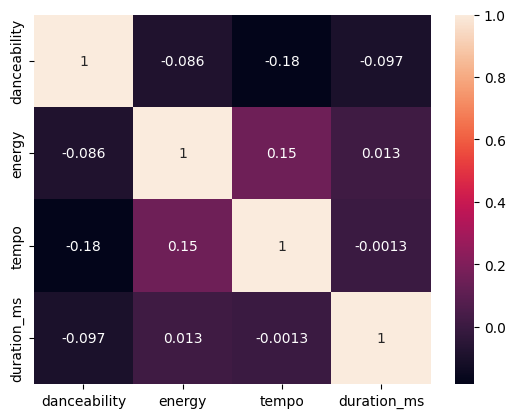

In [20]:
# néhány magyarázó változó összefüggésének mérése (ezeknél volt az a sejtésünk, hogy lehet multikollinearitás)

fokomp = spot[['danceability', 'energy', 'tempo', 'duration_ms']]
korr_matrix = fokomp.corr()
display(korr_matrix)

#heatmap készítése:
sns.heatmap(korr_matrix, annot = True)

A korrelációk gyengék, tehát nem lesz nagy multikollinearitásunk a regresszióban.
Nem meglepő eredmény, hogy minél energikusabb egy zene, annál tempósabb.
Az viszont már jóval érdekesebb, hogy az adatok szerint minél tempósabb egy zene, annál kevésbé táncolható: lehetséges, hogy a nagyon gyors rap és metal számok itt egy kicsi torzítást okoznak, hiszen azokra nem olyan jó táncolni.
Mivel a korrelációk alacsonyak, nem érdemes dimenziót csökkenteni, nem fogunk főkomponenseket készíteni.

C:\Users\Acer\AppData\Local\Temp\ipykernel_22992\2214768679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  box = sns.violinplot(data = spot, x = 'track_popularity', y = 'month', order = honap_sorrend, palette = 'plasma')


[Text(0.5, 1.0, 'Dalok népszerűsége hónapok szerint'),
 Text(0.5, 0, 'Dal népszerűsége'),
 Text(0, 0.5, 'Kiadás hónapja')]

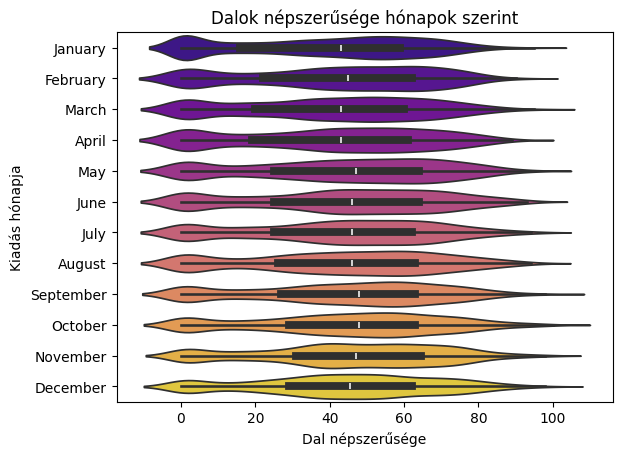

In [ ]:
# év és hónap változó létrehozása

spot['release_date'] = pd.to_datetime(spot['track_album_release_date']) #dátummá alakítás

spot['year'] = spot['release_date'].dt.year
spot['month'] = spot['release_date'].dt.month_name()

#hegedűdiagram készítése a népszerűség hónap szerinti vizsgálatára:

honap_sorrend = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

box = sns.violinplot(data = spot, x = 'track_popularity', y = 'month', order = honap_sorrend, palette = 'plasma')

box.set(title = "Dalok népszerűsége hónapok szerint", xlabel = "Dal népszerűsége", ylabel = "Kiadás hónapja")


Látható, hogy a kiadás hónapja nem befolyásolja erősen a népszerűséget, nincs erős szezonalitás.
Bár a hegedűkön látható, hogy hasonló sűrűséggel vannak dalok az egyes hónapokból, van egy érdekes eredmény: januárban még több népszerűtlen dal van, majd az év vége felé haladva ezek száma elkezd csökkenni és elkezdenek a középmezőnybe kerülni.
Az év vége felé kiadott dalok stabilabb teljesítményt hoznak.
Minden hónapban születnek nagyon sikeres dalok is, nincs egy "arany" hónap.

Text(0.5, 1.02, 'Népszerűség eloszlása műfajok és évek szerint')

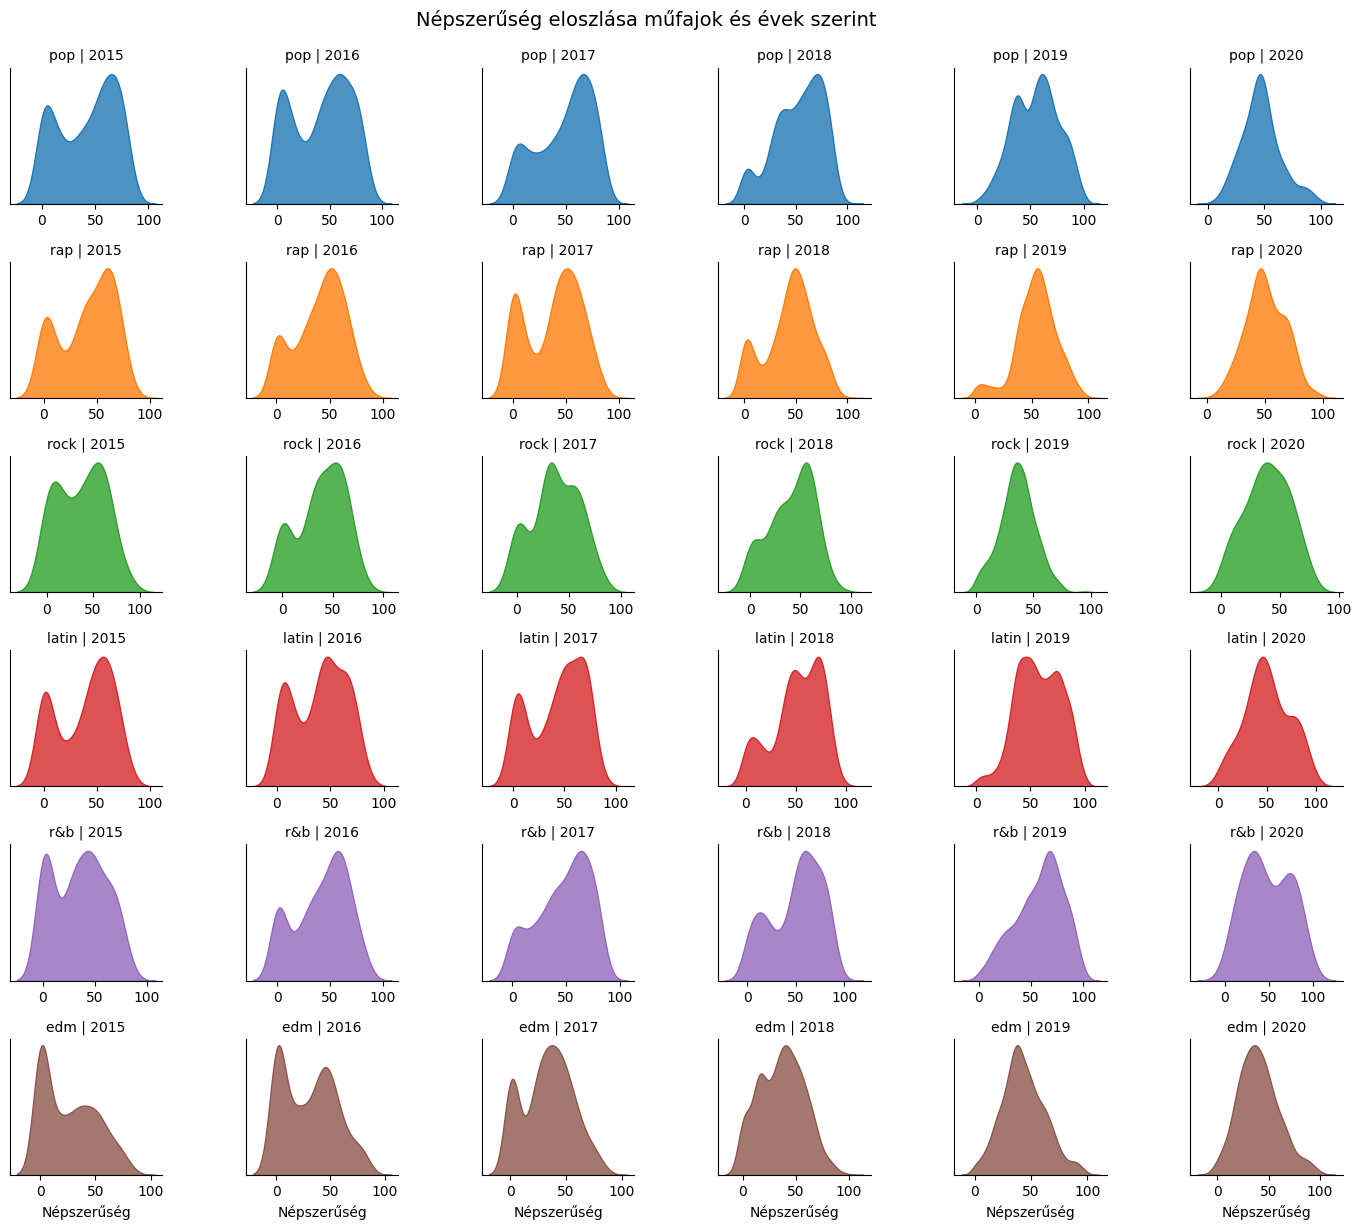

In [3]:
#Ridge plot létrehozása: a népszerűséget egyszerre vizsgáljuk évek és műfajok szerint

spot_uj = spot[spot['year'] >= 2015]

g = sns.FacetGrid(spot_uj, row = 'playlist_genre', col = 'year', hue = 'playlist_genre', aspect = 1.2, height = 2, sharex = False, sharey = False)

g.map(sns.kdeplot, "track_popularity", fill = True, alpha = 0.8)

for ax in g.axes.flat:
    ax.tick_params(labelbottom = True)
    ax.set_xticks([0, 50, 100])

g.set(yticks = [], ylabel = "")

g.set_axis_labels("Népszerűség")
g.set_titles(row_template = "{row_name}", col_template = "{col_name}")
g.fig.suptitle("Népszerűség eloszlása műfajok és évek szerint", y = 1.02, fontsize = 14)

Minden műfaj esetében az évek előrehaladtával elkezdtek eltűnni a nulla közeli értékek: ez azt mutatja, hogy a Spotify algoritmusa egyre hatékonyabban találja meg mindenkinek a neki illő számokat.
A rap műfajban 2015-ben még voltak nem olyan népszerű és nagyon népszerű számok is bőven, 2020-ra azonban a műfaj stabilizálódott, hasonló népszerűségű a legtöbb dal.
Minden műfaj népszerűbbé vált az adatok alapján (ennek alapja a jó algoritmus), viszont a latin és az R&b stílusok különösen nagy sikernek örvendtek 2019-2020 körül.

OLS regresszió készítése:

A hegedűdiagrammunk azt mutatta, hogy az adatokban nincs nagy mértékű szezonalitás, így ezt nem szerepeltetjük a modellben.
A ridge plotunk alapján az évnek (trend) és a műfajnak jelentős hatása lehet, így ezeket beletettük a modellbe.
A 4 elsőre hasonlónak hitt változó között (táncolhatóság, energiaszint, tempó, hossz) nem volt nagy korreláció, így mind szerepelnek a modellben.
Külön érdekességként beletettük a hangnemet is, mert ezzel is érdekes összefüggéseket kaphatunk.

In [4]:
regadat = spot[['track_popularity', 'year', 'playlist_genre', 'danceability', 'energy', 'mode', 'tempo', 'duration_ms']]

modell = smf.ols(formula = "track_popularity ~ year + C(playlist_genre) + danceability + energy + C(mode) + tempo + duration_ms", data = regadat)

eredmeny = modell.fit()

Az R^2 értéke 0,063, azaz a modellünk a zenék népszerűségének 6,3%-át tudta megmagyarázni. 
Bár ez alacsonynak tűnhet, egy olyan kiszámíthatatlan piacon, mint a zeneipar ez egész jó érték, hiszen itt a személyes preferenciák, a szerencse, a marketing és a közösségi média trendek is nagy szerepet játszanak, amiket nem tudtunk mérni.

Az egyetlen változó ami a p-érték szerint nem szignifikáns, az a hangnem. Ez azt mutatja, hogy egy zene népszerűsége nem függ az adataink alapján szignifikánsan attól, hogy dúr vagy moll hangnemben íródott.

A műfajok valóban nagyon sokat számítanak: a referenciaváltozónk az EDM volt, ehhez képest a népszerűségi lista az alábbiak szerint alakul:
1. pop - az, hogy egy szám popszám és nem EDM szám, ceteris paribus 12,03 ponttal növeli a népszerűségét (a többi műfajnál az értelmezés analóg módon történik)
2. rock
3. latin
4. rap
5. r&b
6. EDM

Egyértelmű trend is megfigyelhető a népszerűségben: ha egy szám ceteris paribus 1 évvel később jelent meg, akkor várhatóan kb. 0,13 ponttal lesz nagyobb a népszerűsége.

Minél táncolhatóbb egy szám, annál népszerűbb: minden más változatlansága mellett ez nagyon sokkal növeli a népszerűséget.
Ha egy közepesen táncolható (0,5 értékű) zenét ceteris paribus jól táncolhatóvá (0,8) teszünk, az várhatóan 3,2 ponttal növeli a népszerűségét.

Az energiaszint meglepő módon ellentétes viselkedést mutat: minél energikusabb egy dal, várhatóan annál kevésbé lesz népszerű. Az emberek valószínűleg nem kedvelik a nagyon zajos, kaotikus számokat.

A tempósabb dalok népszerűbbek lehetnek: egy BPM növekedés ceteris paribus 0,02 ponttal növeli a népszerűséget.

A hosszra pont ezt az eredményt vártuk: átszámolva 1 perc hosszúságnövekedés minden más változatlansága mellett 3 pontot vonhat le egy szám népszerűségéből.

C:\Users\Acer\AppData\Local\Temp\ipykernel_22992\2101250206.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = koeffek.sort_values('Együttható'), x = 'Együttható', y = 'Változó', palette = 'coolwarm')


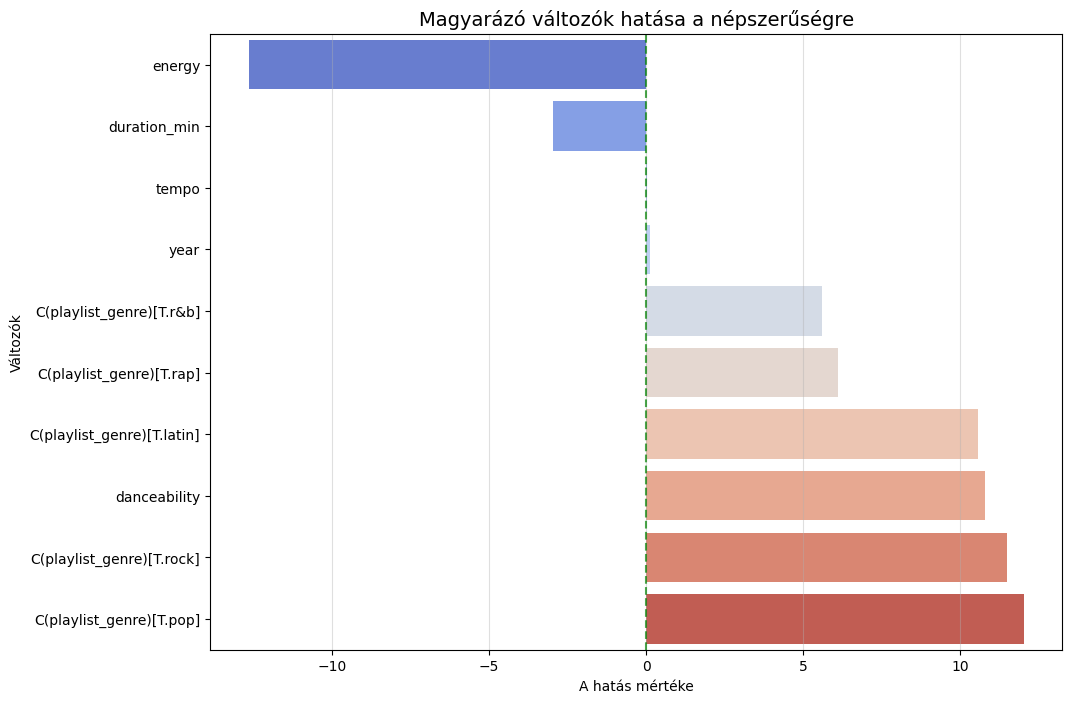

In [ ]:
# készítünk egy barplotot a szignifikáns magyarázó változók hatásáról
# ahhoz, hogy a hossz hatása rendesen kivehető legyen, át kell konvertálni percre

regadat['duration_min'] = regadat['duration_ms'] / 60000
modell = smf.ols(formula = "track_popularity ~ year + C(playlist_genre) + danceability + energy + C(mode) + tempo + duration_min", data = regadat)

eredmeny = modell.fit()



koeffek = eredmeny.params.drop(['Intercept', 'C(mode)[T.1]']).reset_index()
koeffek.columns = ['Változó', 'Együttható']

konf_inter = eredmeny.conf_int().drop(['Intercept', 'C(mode)[T.1]'])
koeffek['Alsó intervallum'] = konf_inter[0].values
koeffek['Felső intervallum'] = konf_inter[1].values

plt.figure(figsize=(11 , 8))
plt.axvline(0, color = 'green', linestyle = '--', alpha = 0.7)

sns.barplot(data = koeffek.sort_values('Együttható'), x = 'Együttható', y = 'Változó', palette = 'coolwarm')

plt.title("Magyarázó változók hatása a népszerűségre", fontsize = 14)
plt.xlabel("A hatás mértéke")
plt.ylabel("Változók")
plt.grid(axis = "x", alpha = 0.4)

plt.show()

# a negatív hatások kék, a pozitívak pedig piros színnel vannak jelölve

In [ ]:
df = pd.read_csv('spotify_songs.csv')

sns.set_theme(style="dark", color_codes=True, rc={"figure.dpi": 300})

subset_df = df.sample(n=3000, random_state=42)

joint_plot = sns.jointplot(
    data=subset_df,
    x="valence", y="energy",
    kind="kde", fill=True,
    cmap="mako",
    thresh=0, levels=100, height=10
)

bg_color = '#121212'

joint_plot.figure.patch.set_facecolor(bg_color)
joint_plot.ax_joint.set_facecolor(bg_color)
joint_plot.ax_marg_x.set_facecolor(bg_color)
joint_plot.ax_marg_y.set_facecolor(bg_color)

joint_plot.ax_joint.tick_params(colors='lightblue')
joint_plot.ax_joint.xaxis.label.set_color('lightblue')
joint_plot.ax_joint.yaxis.label.set_color('lightblue')

joint_plot.ax_marg_x.tick_params(colors='lightblue')
joint_plot.ax_marg_y.tick_params(colors='lightblue')

joint_plot.figure.suptitle("Energia és hangulat sűrűsége", y=1.02, color='white', fontsize=16)
plt.show()


sns.set_theme(style="white", rc={"figure.dpi": 300})

audio_cols = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']
subgenre_means = df.groupby('playlist_subgenre')[audio_cols].mean()

scaled_means = (subgenre_means - subgenre_means.mean()) / subgenre_means.std()

cluster_plot = sns.clustermap(
    scaled_means, cmap="vlag", center=0,
    figsize=(10, 12), linewidths=.75,
    tree_kws={'linewidths': 1.5}
)

cluster_plot.fig.suptitle("Hierarchikus clustermap: alműfajok és jellemzők)", y=1.05, fontsize=18)
plt.show()

In [ ]:
df = pd.read_csv('spotify_songs.csv')
sub_stats = df.groupby('playlist_subgenre')[['danceability', 'energy', 'valence']].mean().reset_index()

sub_stats = sub_stats.sort_values('playlist_subgenre').reset_index(drop=True)
sub_stats['id'] = sub_stats.index +  1

sub_stats_ordered = sub_stats.sort_values('danceability', ascending=False).reset_index(drop=True)

sns.set_theme(style="darkgrid", rc={
    "figure.dpi": 300,
    "axes.facecolor": "#0F0F1A",
    "figure.facecolor": "#0F0F1A",
    "axes.edgecolor": "#333344",
    "grid.color": "#333344"
})

fig, ax = plt.subplots(figsize=(15, 10))

en_low, en_high = sub_stats['energy'].min(), sub_stats['energy'].max()
val_low, val_high = sub_stats['valence'].min(), sub_stats['valence'].max()

mid_x = (en_low + en_high) / 2
mid_y = (val_low + val_high) / 2

widest_gap = max(en_high - en_low, val_high - val_low)

padding = 1.1
scope = (widest_gap * padding) / 2

ax.set_xlim(mid_x - scope, mid_x + scope)
ax.set_ylim(mid_y - scope, mid_y + scope)
ax.set_aspect('equal', adjustable='box')

scatter = sns.scatterplot(
    data=sub_stats_ordered,
    x="energy",
    y="valence",
    hue="danceability",
    size="danceability",
    sizes=(180, 1100),
    palette = "magma" ,
    edgecolor="#f3f6f4",
    linewidth=1,
    alpha=0.9,
    ax=ax,
    zorder=5
)

cmap = mpl.colormaps['magma']
color_norm = mpl.colors.Normalize(vmin=sub_stats['danceability'].min(), vmax=sub_stats['danceability'].max())

for i in range(sub_stats_ordered.shape[0]):
    row = sub_stats_ordered.iloc[i]
    rgba = cmap(color_norm(row['danceability']))
    brightness = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
    lbl_color = 'black' if brightness > 0.5 else 'white'

    ax.text(
        row['energy'],
        row['valence'],
        str(int(row['id'])),
        color=lbl_color,
        fontsize=9,
        weight='heavy',
        family='sans-serif',
        ha='center',
        va='center',
        zorder=10
    )

outliers = pd.concat([
    sub_stats.nlargest(2, 'energy'),
    sub_stats.nsmallest(2, 'energy'),
    sub_stats.nlargest(2, 'valence'),
    sub_stats.nsmallest(2, 'valence')
]).drop_duplicates()

min_d = sub_stats['danceability'].min()
max_d = sub_stats['danceability'].max()

for i in range(outliers.shape[0]):
    row = outliers.iloc[i]
    d_ratio = (row['danceability'] - min_d) / (max_d - min_d)
    y_nudge = 0.012 + (d_ratio * 0.01)

    if row['id'] in [14, 20]:
        final_y = row['valence'] - y_nudge
        v_pos = 'top'
    else:
        final_y = row['valence'] + y_nudge
        v_pos = 'bottom'

    ax.text(
        row['energy'],
        final_y,
        row['playlist_subgenre'].upper(),
        color='#FFFFFF',
        fontsize=8,
        weight='bold',
        ha='center',
        va=v_pos,
        zorder=15,
        bbox=dict(facecolor='#000000', alpha=0.6, edgecolor='lightblue', boxstyle='round,pad=0.3', lw=1)
    )

ax.set_title("Zenei alműfajok jellemzői", color="white", fontsize=20, weight="bold", pad=20)
ax.set_xlabel("Energiaszint  ", color="lightblue", fontsize=14, weight="bold")
ax.set_ylabel("Pozitivitás", color="lightblue", fontsize=14, weight="bold")
ax.tick_params(colors="darkgrey", labelsize=11)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(
    handles, labels,
    title="Táncolhatóság (Méret)",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=True,
    labelspacing=3.2,
    borderpad=2
)
plt.setp(leg.get_texts(), color='lightgrey')
plt.setp(leg.get_title(), color='white', weight='bold')

split_point = len(sub_stats) // 2
txt_part1 = "JELMAGYARÁZAT:  \n\n" + "\n".join([f"{row['id']:02d} - {row['playlist_subgenre']}" for _, row in sub_stats.iloc[:split_point].iterrows()])
txt_part2 = "\n\n" + "\n".join([f"{row['id']:02d} - {row['playlist_subgenre']}" for _, row in sub_stats.iloc[split_point:].iterrows()])

ax.text(1.05, 0.4, txt_part1, transform=ax.transAxes, color='lightblue', fontsize=11, weight='bold', va='top', family='monospace')
ax.text(1.32, 0.4, txt_part2, transform=ax.transAxes, color='lightblue', fontsize=11, weight='bold', va='top', family='monospace')

plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv('spotify_songs.csv')

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0), "axes.titlesize": 16, "figure.dpi": 300})

music_genres = df['playlist_genre'].unique()
genre_palette = sns.cubehelix_palette(len(music_genres), rot=-.25, light=.7)

ridge_fig = sns.FacetGrid(df, row="playlist_genre", hue="playlist_genre", aspect=10, height=1.2, palette=genre_palette)

ridge_fig.map(sns.kdeplot, "valence", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
ridge_fig.map(sns.kdeplot, "valence", clip_on=False, color="w", lw=2, bw_adjust=.5)
ridge_fig.map(plt.axhline, y=0, lw=2, clip_on=False)

def draw_text_label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label.capitalize(), fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes, fontsize=12)

def add_stats_label(x, color, **kwargs):
    ax = plt.gca()
    mean_val = x.mean()
    std_val = x.std()

    stats_text = f"Átlag: {mean_val:.2f}  |  STD: {std_val:.2f}"

    ax.text(1.02, 0.2, stats_text, color="#444444",
            fontsize=10, fontweight="bold", ha="left", va="center",
            transform=ax.transAxes)

ridge_fig.map(draw_text_label, "valence")
ridge_fig.map(add_stats_label, "valence")

ridge_fig.figure.subplots_adjust(hspace=-.4, right=0.8)

ridge_fig.set_titles("")
ridge_fig.set(yticks=[], ylabel="", xlabel="Pozitivitás")
ridge_fig.despine(bottom=True, left=True)

ridge_fig.figure.suptitle("A zenei műfajok pozitivitása", y=1)
plt.show()